# CornerDetector — Kaggle T4 GPU Egitimi

**Baslamadan once:** Sag panelde **Accelerator: GPU T4 x2** sec.

Egitim bittikten sonra checkpoint'i **Output** sekmesinden indir.

In [1]:
# 1. GPU kontrol
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('GPU YOK — sag panelden Accelerator > GPU T4 x2 sec!')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# 2. Repo + bagimliliklar
import os
!git clone https://github.com/HeliumNitrate/checkerboard-corner-detector.git /kaggle/working/ccd
!pip install timm>=0.9 --quiet
import timm
print('timm:', timm.__version__)

Cloning into '/kaggle/working/ccd'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 51 (delta 19), reused 41 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 29.64 KiB | 7.41 MiB/s, done.
Resolving deltas: 100% (19/19), done.
timm: 1.0.25


In [3]:
# 3. Model testi
import sys, os

CNN_DIR = '/kaggle/working/ccd'
os.chdir(CNN_DIR)
if CNN_DIR not in sys.path:
    sys.path.insert(0, CNN_DIR)

import torch
from model.detector import CornerDetector

m = CornerDetector(pretrained=True)
n = sum(p.numel() for p in m.parameters())
x = torch.zeros(1, 3, 256, 256).cuda() if torch.cuda.is_available() else torch.zeros(1, 3, 256, 256)
m = m.cuda() if torch.cuda.is_available() else m
out = m(x)
print(f'Params : {n/1e6:.2f}M')
print(f'Output : {list(out.shape)}')
print('Model OK!')

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Params : 21.92M
Output : [1, 1, 256, 256]
Model OK!


In [4]:
# 4. EGITIM
# ~830s/epoch x 35 epoch = ~8 saat
# Save Version > Save & Run All ile calistir — bittikten sonra Output'tan indir

import sys, os, argparse

CNN_DIR = '/kaggle/working/ccd'
os.chdir(CNN_DIR)
if CNN_DIR not in sys.path:
    sys.path.insert(0, CNN_DIR)

CKPT = os.path.join('/kaggle/working', 'model.pt')
print('Checkpoint kaydedilecek:', CKPT)

from train import train

args = argparse.Namespace(
    epochs     = 35,
    batch      = 16,
    n_train    = 8000,
    n_val      = 1000,
    img_size   = 256,
    lr         = 1e-4,
    workers    = 2,
    save       = CKPT,
    pretrained = True,
    resume     = False,
)

train(args)
print('Egitim tamamlandi. Output sekmesinden model.pt indir.')

Checkpoint kaydedilecek: /kaggle/working/model.pt
Device : cuda


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Parameters : 21.92M
Epoch   1/35  train 0.0313  val 0.0170  prec 0.702  rec 0.997  lr 1.0e-04  906s
  >> checkpoint saved  (val 0.0170)
Epoch   2/35  train 0.0136  val 0.0116  prec 0.902  rec 0.994  lr 9.9e-05  896s
  >> checkpoint saved  (val 0.0116)
Epoch   3/35  train 0.0101  val 0.0094  prec 0.946  rec 0.994  lr 9.8e-05  903s
  >> checkpoint saved  (val 0.0094)
Epoch   4/35  train 0.0088  val 0.0085  prec 0.973  rec 0.994  lr 9.7e-05  909s
  >> checkpoint saved  (val 0.0085)
Epoch   5/35  train 0.0081  val 0.0079  prec 0.983  rec 0.996  lr 9.5e-05  900s
  >> checkpoint saved  (val 0.0079)
Epoch   6/35  train 0.0078  val 0.0077  prec 0.990  rec 0.996  lr 9.3e-05  893s
  >> checkpoint saved  (val 0.0077)
Epoch   7/35  train 0.0075  val 0.0076  prec 0.991  rec 0.997  lr 9.1e-05  863s
  >> checkpoint saved  (val 0.0076)
Epoch   8/35  train 0.0074  val 0.0074  prec 0.994  rec 0.997  lr 8.8e-05  858s
  >> checkpoint saved  (val 0.0074)
Epoch   9/35  train 0.0073  val 0.0073  prec 0.996  

In [5]:
# 5. Sonuc kontrol
import torch, os

CKPT = os.path.join('/kaggle/working', 'model.pt')
ckpt = torch.load(CKPT, map_location='cpu')
print('Checkpoint OK!')
print('  En iyi epoch :', ckpt['epoch'])
print('  Val loss     :', round(ckpt['val_loss'], 4))

Checkpoint OK!
  En iyi epoch : 35
  Val loss     : 0.007


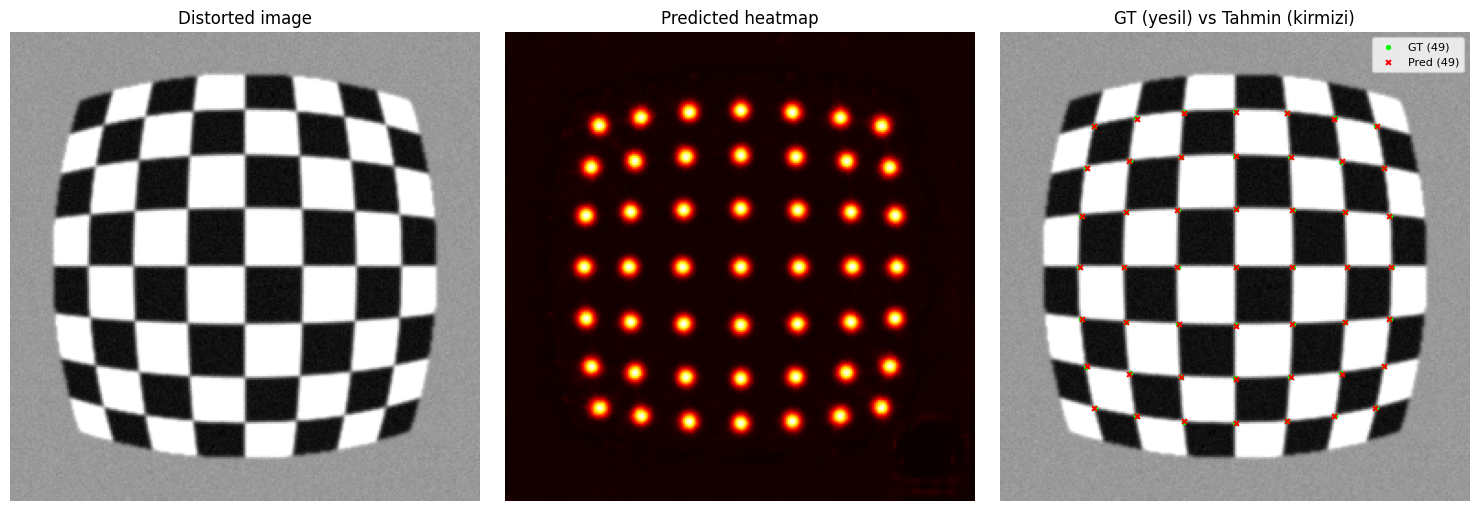

/kaggle/working/inference_test.png

inference_test.png indir veya yukarda gorsel olarak gozukuyor.


In [6]:
# 6. Gorsel test
import sys, os

CNN_DIR = '/kaggle/working/ccd'
os.chdir(CNN_DIR)
if CNN_DIR not in sys.path:
    sys.path.insert(0, CNN_DIR)

import torch, numpy as np
import matplotlib.pyplot as plt
from model.detector import CornerDetector
from data.synthesize import generate_sample
from infer import predict_heatmap, heatmap_to_corners

CKPT   = os.path.join('/kaggle/working', 'model.pt')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt   = torch.load(CKPT, map_location=device)
model  = CornerDetector(pretrained=False).to(device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

rng    = np.random.default_rng(99)
sample = generate_sample(img_size=256, rng=rng)
img    = sample['image']
gt_corners = sample['corners'].reshape(-1, 2)
gt_valid   = gt_corners[~np.isnan(gt_corners[:, 0])]

heatmap      = predict_heatmap(model, img, device=device)
pred_corners = heatmap_to_corners(heatmap, min_distance=8, threshold=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Distorted image'); axes[0].axis('off')
axes[1].imshow(heatmap, cmap='hot'); axes[1].set_title('Predicted heatmap'); axes[1].axis('off')
axes[2].imshow(img, cmap='gray')
axes[2].scatter(gt_valid[:, 1],     gt_valid[:, 0],     s=8,  c='lime', label=f'GT ({len(gt_valid)})')
axes[2].scatter(pred_corners[:, 1], pred_corners[:, 0], s=12, c='red',  marker='x', label=f'Pred ({len(pred_corners)})')
axes[2].set_title('GT (yesil) vs Tahmin (kirmizi)'); axes[2].legend(fontsize=8); axes[2].axis('off')
plt.tight_layout()
out_img = os.path.join('/kaggle/working', 'inference_test.png')
plt.savefig(out_img, dpi=150)
plt.show()

from IPython.display import FileLink, display
display(FileLink(out_img))
print('inference_test.png indir veya yukarda gorsel olarak gozukuyor.')